# Memory Experiment — [[6, 2, 2]] H-code

Build a bare-qubit memory experiment for `HSixCode`, the self-dual `[[6, 2, 2]]`
CSS code (`k = 2`, `d = 2`) that is the base code of Quantinuum's Magic-H6 `|H>`
distillation protocol ([arXiv:2506.14688](https://arxiv.org/abs/2506.14688)).

The code has no 2D locality, so `HSixExtractionBlock` is LightStim's generic CSS
coloration block (`GenericCSSColorationExtractionBlock`) — the same choice the
Kasai codes make; `MemoryExperiment` picks it up automatically. The `O(p^2)`
slope check is in `tests/test_H_six_fault_distance.py`; the encoded-`|00>_L`
variant is `lightstim/protocols/h_six_encoded_memory.py`, and the full Magic-H6
roadmap audit is in `playground/magic_h6/`.

In [1]:
import sys
from pathlib import Path

ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "lightstim").is_dir() and (path / "pyproject.toml").exists()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np

from lightstim.noise.config import NoiseConfig
from lightstim.protocols import MemoryExperiment
from lightstim.qec_code.H_six import HSixCode

## Code

```
S^X_1 = X0 X1 X2 X3      S^Z_1 = Z0 Z1 Z2 Z3
S^X_2 = X2 X3 X4 X5      S^Z_2 = Z2 Z3 Z4 Z5
X0_L  = X0 X2 X4         Z0_L  = Z0 Z2 Z4
X1_L  = X1 X3 X5         Z1_L  = Z1 Z3 Z5
```

The X and Z checks share support (`Hx == Hz`) → self-dual: transversal `H` is
logical `H`. Data qubit `i` sits at `(2i, 0)`; X ancillas on `y = +1`, Z ancillas
on `y = -1`.

In [2]:
code = HSixCode()
info = code.get_info()
print({k: info[k] for k in ("code_distance", "k", "n_data",
                            "num_x_syndromes", "num_z_syndromes", "num_logicals")})

Hx, Hz = code.get_parity_check_matrix()
assert np.array_equal(Hx, Hz) and np.all((Hx @ Hz.T) % 2 == 0)
print("self-dual (Hx == Hz):", np.array_equal(Hx, Hz))

for s in code.stabilizers:
    print(f"  {s['type']}-check  data {s['data_indices']}  ancilla {s['syn_idx']}")
for op in code.logical_ops:
    print(f"  {op['type']}{op['data_indices']}")

{'code_distance': 2, 'k': 2, 'n_data': 6, 'num_x_syndromes': 2, 'num_z_syndromes': 2, 'num_logicals': 2}
self-dual (Hx == Hz): True
  X-check  data [0, 1, 2, 3]  ancilla 6
  X-check  data [2, 3, 4, 5]  ancilla 7
  Z-check  data [0, 1, 2, 3]  ancilla 8
  Z-check  data [2, 3, 4, 5]  ancilla 9
  X[0, 2, 4]
  Z[0, 2, 4]
  X[1, 3, 5]
  Z[1, 3, 5]


## Build the memory circuit

`MemoryExperiment` initializes the six data qubits in the memory basis, runs
`rounds` native SE rounds (the tracker auto-generates every stabilizer detector),
then reads the data out. Noiseless, all detectors and both observables are
deterministically zero, in either basis.

In [3]:
SHOTS = 64

def build_memory(basis, rounds=3):
    circuit = MemoryExperiment(
        qec_patch=HSixCode(), rounds=rounds, basis=basis, if_detector=True
    ).build().without_noise()
    sample = circuit.compile_detector_sampler().sample(SHOTS, append_observables=True)
    assert not sample.any()
    circuit.detector_error_model(decompose_errors=True)
    print(f"basis {basis}: qubits={circuit.num_qubits}  "
          f"detectors={circuit.num_detectors}  observables={circuit.num_observables}  "
          f"noiseless all-zero=True")
    return circuit

circuits = {basis: build_memory(basis) for basis in ("Z", "X")}

basis Z: qubits=10  detectors=12  observables=2  noiseless all-zero=True
basis X: qubits=10  detectors=12  observables=2  noiseless all-zero=True


## Detector-slice view

stim's built-in `detslice-with-ops-svg`, sliced to the second SE round
(`tick=range(12, 24)`). That round contributes four detectors: two X checks
(red, on the `y = +1` ancilla row) and two Z checks (blue, `y = -1`), each pair
over data qubits `{0, 1, 2, 3}` and `{2, 3, 4, 5}`. The X and Z detectors
covering the *same* data supports is the self-dual signature of the `[[6, 2, 2]]`
code; the `y = +1` / `y = -1` split is just the ancilla-row convention.

The first SE round and the final data readout carry Z-only detectors here
(Z-basis memory): `|0...0>` fixes only the Z stabilizers, and a Z-basis readout
reconstructs only Z detectors — the standard memory time-boundary behaviour.

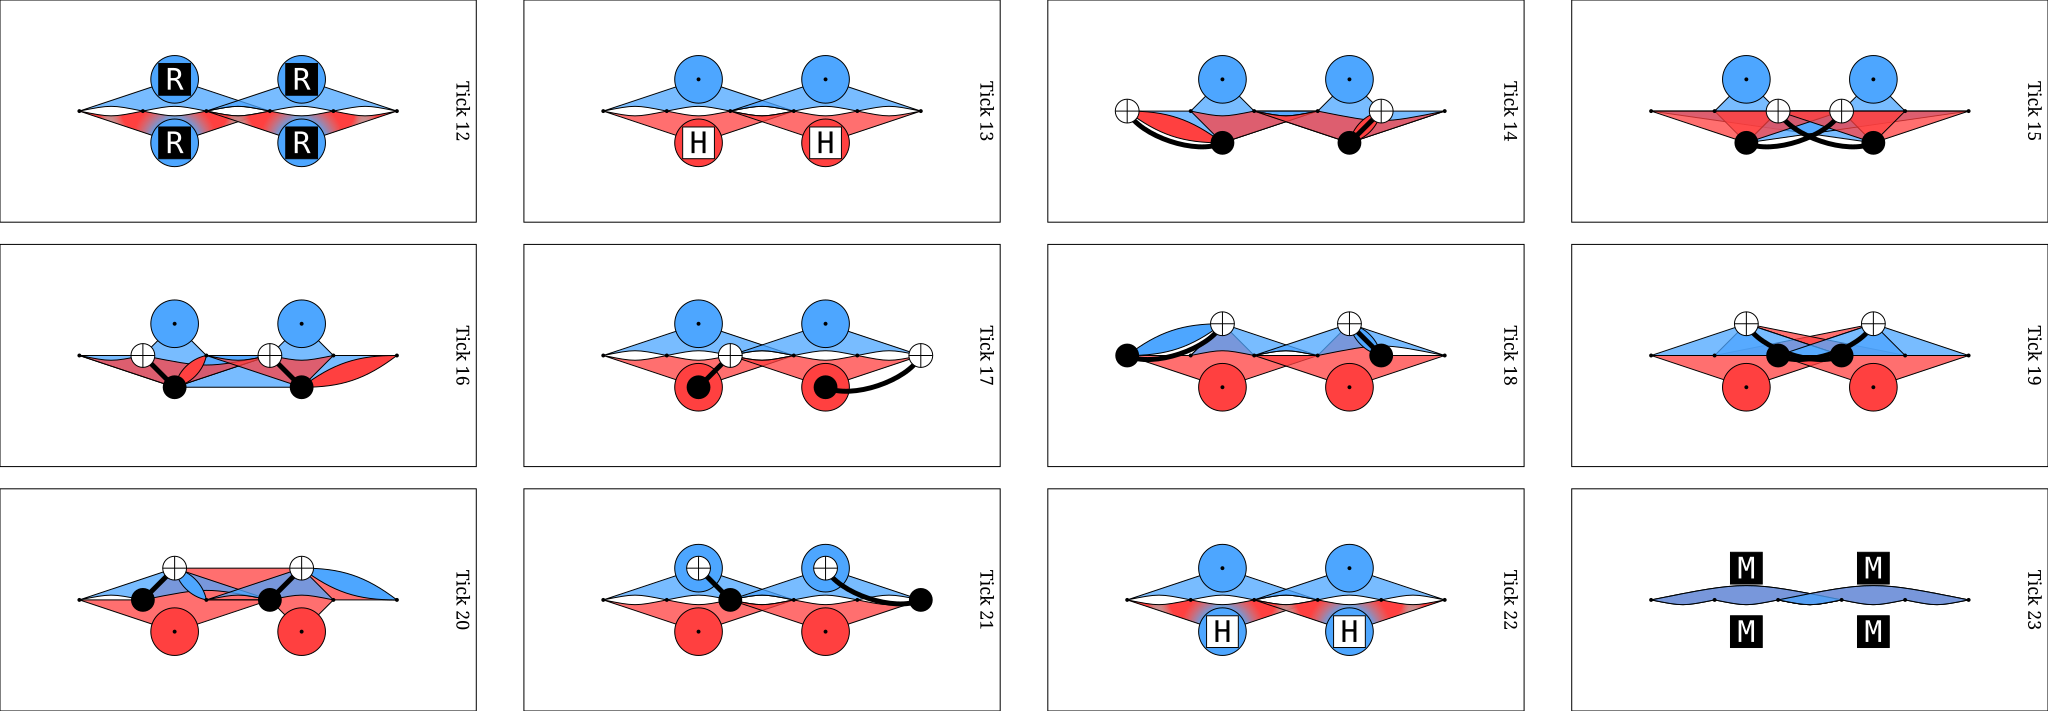

In [4]:
circuits["Z"].diagram("detslice-with-ops-svg", tick=range(12, 24))

## Circuit fault distance

`[[6, 2, 2]]` is error-*detecting* (`d = 2`): under circuit-level noise, stim's
`shortest_graphlike_error` has length 2 in both bases (the full
`ignore_ungraphlike_errors=False` search agrees), so no single fault flips a
logical undetected — the conditional logical-error rate under detector
post-selection is `O(p^2)`. (Showing the `O(p^2)` slope needs a multi-`p` sweep;
that lives in
`tests/test_H_six_fault_distance.py::test_baseline_memory_conditional_ler_is_quadratic`.)

In [5]:
p = 1e-3
for basis in ("Z", "X"):
    noisy = MemoryExperiment(
        qec_patch=HSixCode(), rounds=3, basis=basis,
        noise_params=NoiseConfig(p_1q=p, p_2q=p, p_meas=p, p_reset=p),
        noise_model="circuit_level",
    ).build()
    graphlike = len(noisy.shortest_graphlike_error())
    full = len(noisy.shortest_graphlike_error(ignore_ungraphlike_errors=False))
    print(f"basis {basis}: circuit fault distance {full}  (graphlike bound {graphlike})")
    assert graphlike >= 2 and full >= 2

basis Z: circuit fault distance 2  (graphlike bound 2)
basis X: circuit fault distance 2  (graphlike bound 2)
